In [1]:
import pandas as pd


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/raw_stock_data.csv', header=[0,1], index_col=0, parse_dates=True)

In [4]:
print(data.head())


Price              Close                                                     \
Ticker     BHARTIARTL.NS HDFCBANK.NS HINDUNILVR.NS ICICIBANK.NS     INFY.NS   
Date                                                                          
2019-01-01    280.425446  504.392548   1607.500488   350.957001  541.725708   
2019-01-02    274.413177  499.790222   1592.774048   351.777130  544.984131   
2019-01-03    275.159271  495.868896   1596.165894   350.474609  545.065674   
2019-01-04    283.014679  497.195587   1590.185913   352.356049  538.467651   
2019-01-07    285.208923  497.946899   1593.086548   354.768097  547.142700   

Price                                                    High              \
Ticker     RELIANCE.NS       TCS.NS     TMPV.NS BHARTIARTL.NS HDFCBANK.NS   
Date                                                                        
2019-01-01  496.196381  1561.000488  170.382263    282.619698  505.073470   
2019-01-02  489.733887  1577.817871  165.568924    281.7419

In [5]:
print(data.columns)

MultiIndex([( 'Close', 'BHARTIARTL.NS'),
            ( 'Close',   'HDFCBANK.NS'),
            ( 'Close', 'HINDUNILVR.NS'),
            ( 'Close',  'ICICIBANK.NS'),
            ( 'Close',       'INFY.NS'),
            ( 'Close',   'RELIANCE.NS'),
            ( 'Close',        'TCS.NS'),
            ( 'Close',       'TMPV.NS'),
            (  'High', 'BHARTIARTL.NS'),
            (  'High',   'HDFCBANK.NS'),
            (  'High', 'HINDUNILVR.NS'),
            (  'High',  'ICICIBANK.NS'),
            (  'High',       'INFY.NS'),
            (  'High',   'RELIANCE.NS'),
            (  'High',        'TCS.NS'),
            (  'High',       'TMPV.NS'),
            (   'Low', 'BHARTIARTL.NS'),
            (   'Low',   'HDFCBANK.NS'),
            (   'Low', 'HINDUNILVR.NS'),
            (   'Low',  'ICICIBANK.NS'),
            (   'Low',       'INFY.NS'),
            (   'Low',   'RELIANCE.NS'),
            (   'Low',        'TCS.NS'),
            (   'Low',       'TMPV.NS'),
            (  '

In [6]:
print(data.index)

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-01-07', '2019-01-08', '2019-01-09', '2019-01-10',
               '2019-01-11', '2019-01-14',
               ...
               '2026-06-04', '2026-06-05', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-15',
               '2026-06-16', '2026-06-17'],
              dtype='datetime64[ns]', name='Date', length=1844, freq=None)


In [7]:
# Extract just the Close prices for all 8 stocks
close_prices = data['Close']
print(close_prices.head())
print(close_prices.shape)

Ticker      BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS  \
Date                                                                  
2019-01-01     280.425446   504.392548    1607.500488    350.957001   
2019-01-02     274.413177   499.790222    1592.774048    351.777130   
2019-01-03     275.159271   495.868896    1596.165894    350.474609   
2019-01-04     283.014679   497.195587    1590.185913    352.356049   
2019-01-07     285.208923   497.946899    1593.086548    354.768097   

Ticker         INFY.NS  RELIANCE.NS       TCS.NS     TMPV.NS  
Date                                                          
2019-01-01  541.725708   496.196381  1561.000488  170.382263  
2019-01-02  544.984131   489.733887  1577.817871  165.568924  
2019-01-03  545.065674   483.691925  1558.662476  163.113144  
2019-01-04  538.467651   486.303467  1539.711914  167.926468  
2019-01-07  547.142700   489.003540  1556.980469  172.248657  
(1844, 8)


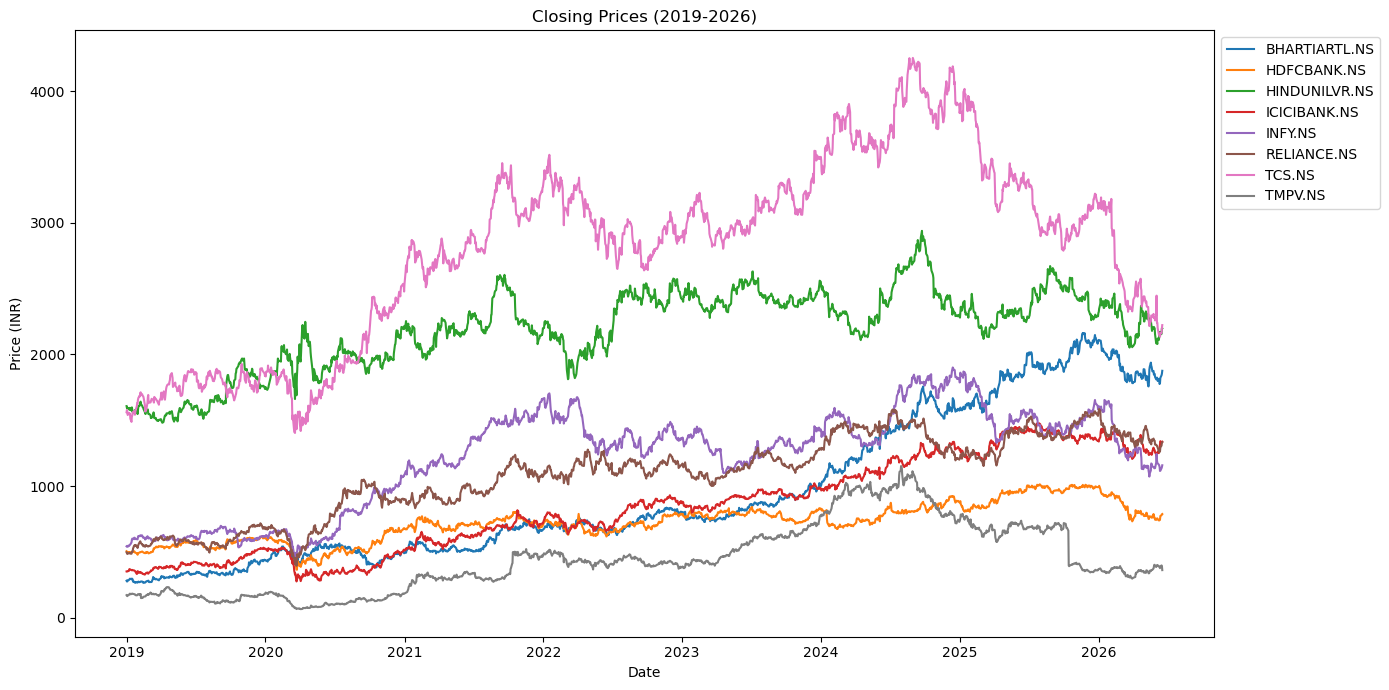

In [8]:
plt.figure(figsize=(14, 7))
for stock in close_prices.columns:
    plt.plot(close_prices.index, close_prices[stock], label=stock)

plt.title('Closing Prices (2019-2026)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

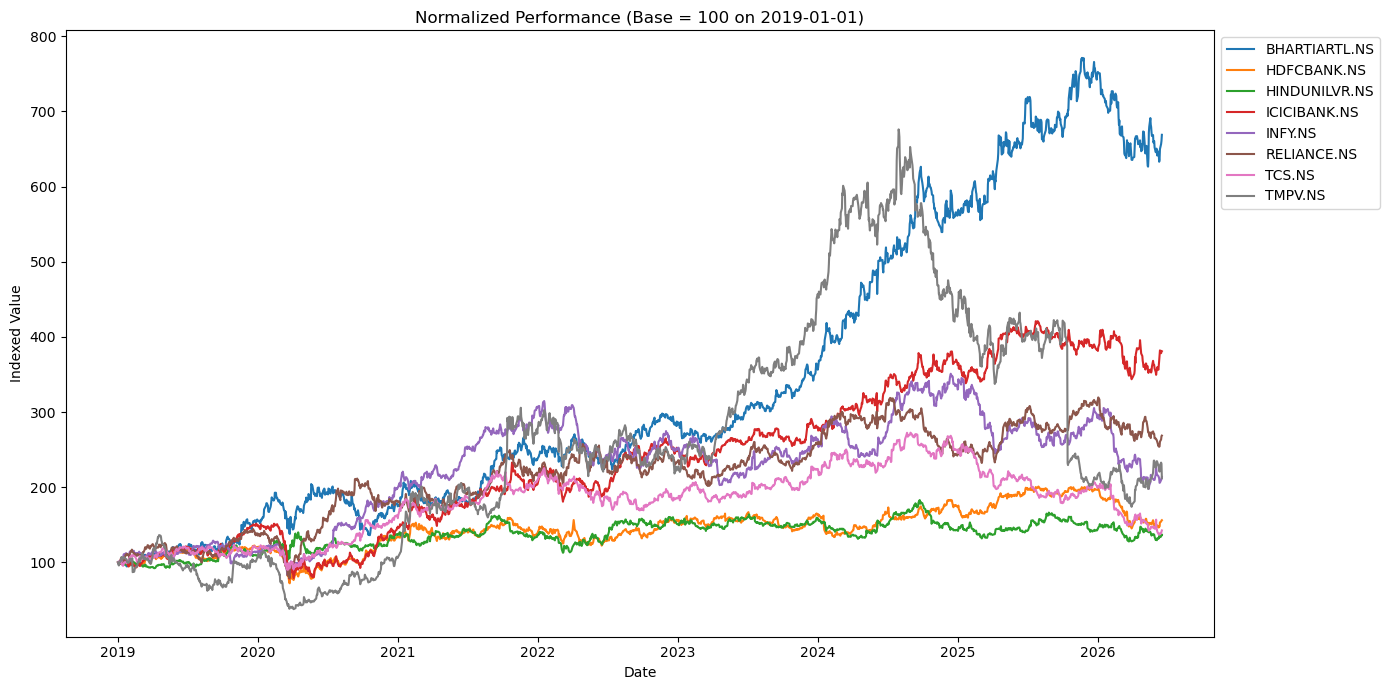

In [9]:
normalized = close_prices / close_prices.iloc[0] * 100

plt.figure(figsize=(14, 7))
for stock in normalized.columns:
    plt.plot(normalized.index, normalized[stock], label=stock)

plt.title('Normalized Performance (Base = 100 on 2019-01-01)')
plt.xlabel('Date')
plt.ylabel('Indexed Value')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

In [10]:
daily_returns = close_prices.pct_change().dropna()
print(daily_returns.head())
print(daily_returns.describe())


Ticker      BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS   INFY.NS  \
Date                                                                            
2019-01-02      -0.021440    -0.009124      -0.009161      0.002337  0.006015   
2019-01-03       0.002719    -0.007846       0.002130     -0.003703  0.000150   
2019-01-04       0.028549     0.002675      -0.003746      0.005368 -0.012105   
2019-01-07       0.007753     0.001511       0.001824      0.006845  0.016111   
2019-01-08       0.013233    -0.008323      -0.007900      0.033859 -0.002456   

Ticker      RELIANCE.NS    TCS.NS   TMPV.NS  
Date                                         
2019-01-02    -0.013024  0.010773 -0.028250  
2019-01-03    -0.012337 -0.012140 -0.014832  
2019-01-04     0.005399 -0.012158  0.029509  
2019-01-07     0.005552  0.011215  0.025739  
2019-01-08    -0.000091 -0.002292  0.026233  
Ticker  BHARTIARTL.NS  HDFCBANK.NS  HINDUNILVR.NS  ICICIBANK.NS      INFY.NS  \
count     1843.000000  1843.00

In [11]:
worst_day = daily_returns['TMPV.NS'].idxmin()
print(worst_day)
print(daily_returns['TMPV.NS'].loc[worst_day])

2025-10-14 00:00:00
-0.40151341323188605


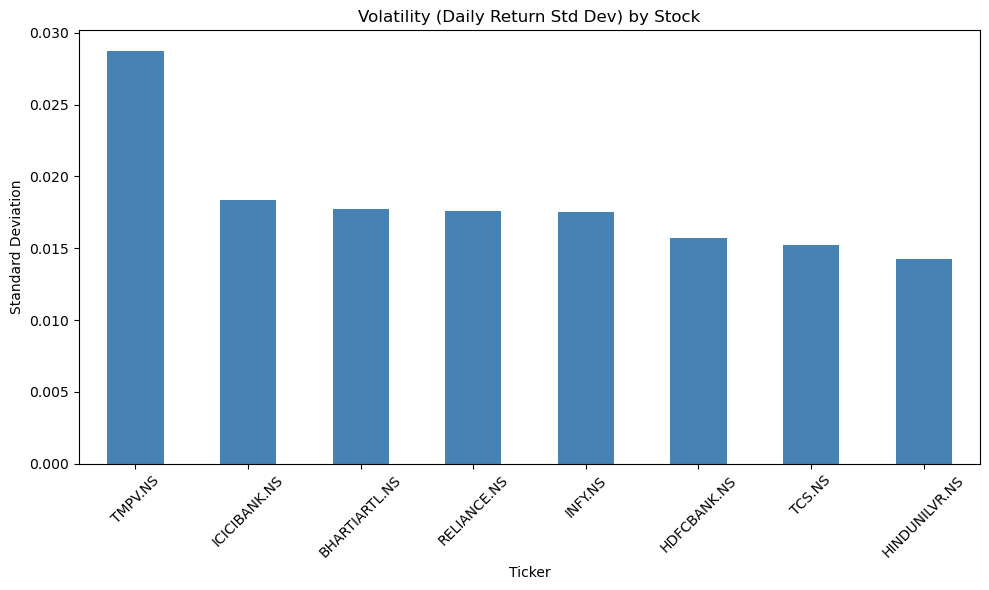

Ticker
TMPV.NS          0.028734
ICICIBANK.NS     0.018372
BHARTIARTL.NS    0.017729
RELIANCE.NS      0.017563
INFY.NS          0.017491
HDFCBANK.NS      0.015742
TCS.NS           0.015223
HINDUNILVR.NS    0.014232
dtype: float64


In [12]:
volatility = daily_returns.std().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
volatility.plot(kind='bar', color='steelblue')
plt.title('Volatility (Daily Return Std Dev) by Stock')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(volatility)

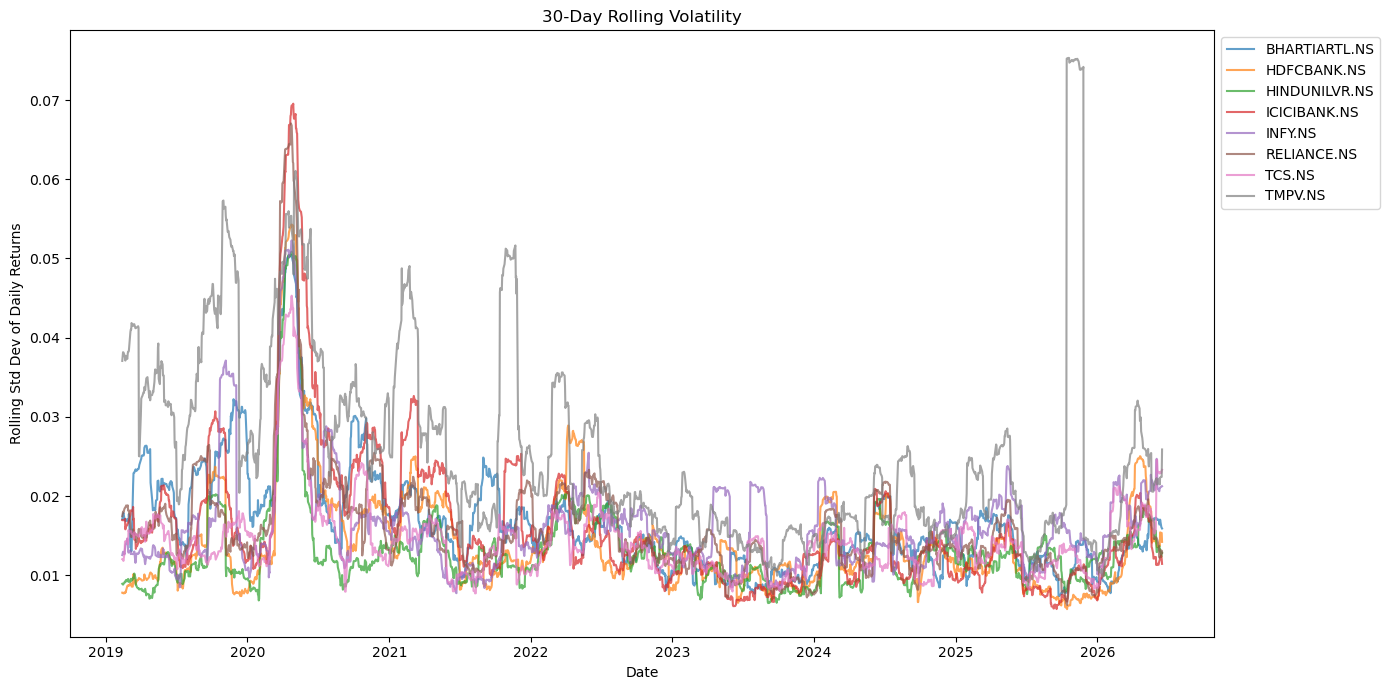

In [13]:
rolling_vol = daily_returns.rolling(window=30).std()

plt.figure(figsize=(14, 7))
for stock in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[stock], label=stock, alpha=0.7)

plt.title('30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Rolling Std Dev of Daily Returns')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

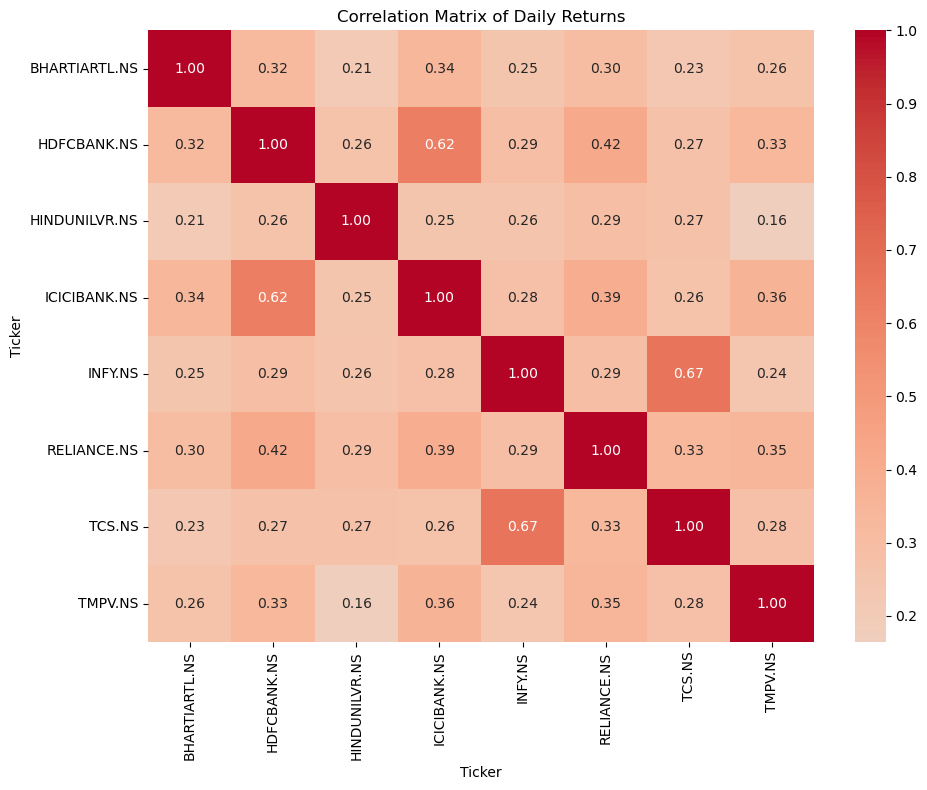

In [14]:
correlation_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Daily Returns')
plt.tight_layout()
plt.show()


In [ ]:
tmpv_returns = daily_returns['TMPV.NS']
std_with_outlier = tmpv_returns.std()
std_without_outlier = tmpv_returns.drop(pd.Timestamp('2025-10-14')).std()

print(f"TMPV std with demerger day: {std_with_outlier:.6f}")
print(f"TMPV std without demerger day: {std_without_outlier:.6f}")